# Exercise 7

# Capital Bikeshare data

## Introduction

- Capital Bikeshare dataset from Kaggle: [data](https://github.com/justmarkham/DAT8/blob/master/data/bikeshare.csv), [data dictionary](https://www.kaggle.com/c/bike-sharing-demand/data)
- Each observation represents the bikeshare rentals initiated during a given hour of a given day

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz

In [2]:
# read the data and set "datetime" as the index
url = 'https://raw.githubusercontent.com/justmarkham/DAT8/master/data/bikeshare.csv'
bikes = pd.read_csv(url, index_col='datetime', parse_dates=True)

In [3]:
# "count" is a method, so it's best to rename that column
bikes.rename(columns={'count':'total'}, inplace=True)

In [4]:
# create "hour" as its own feature
bikes['hour'] = bikes.index.hour

In [5]:
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


In [6]:
bikes.tail()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2012-12-19 19:00:00,4,0,1,1,15.58,19.695,50,26.0027,7,329,336,19
2012-12-19 20:00:00,4,0,1,1,14.76,17.425,57,15.0013,10,231,241,20
2012-12-19 21:00:00,4,0,1,1,13.94,15.910,61,15.0013,4,164,168,21
2012-12-19 22:00:00,4,0,1,1,13.94,17.425,61,6.0032,12,117,129,22
2012-12-19 23:00:00,4,0,1,1,13.12,16.665,66,8.9981,4,84,88,23


- **hour** ranges from 0 (midnight) through 23 (11pm)
- **workingday** is either 0 (weekend or holiday) or 1 (non-holiday weekday)

# Exercise 7.1

Run these two `groupby` statements and figure out what they tell you about the data.

In [7]:
# mean rentals for each value of "workingday"
bikes.groupby('workingday').total.mean()

workingday
0    188.506621
1    193.011873
Name: total, dtype: float64

In [8]:
# mean rentals for each value of "hour"
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

From the statistics, the total bike rented is slightly higher in the working day which indicates that some bikes were used for working, however, most of the bikes was used for purposed other than just working.

Let's see the use of bike in a day, hourly. We can see the number increase and decrease gradually with one global maximum, and one global minimum. We can conclude that people start using bike after waking up, at 5am, and during days bike was used regularly before the bike usage peaked at the time after working, at around 5pm.

# Exercise 7.2

Run this plotting code, and make sure you understand the output. Then, separate this plot into two separate plots conditioned on "workingday". (In other words, one plot should display the hourly trend for "workingday=0", and the other should display the hourly trend for "workingday=1".)

<Axes: xlabel='hour'>

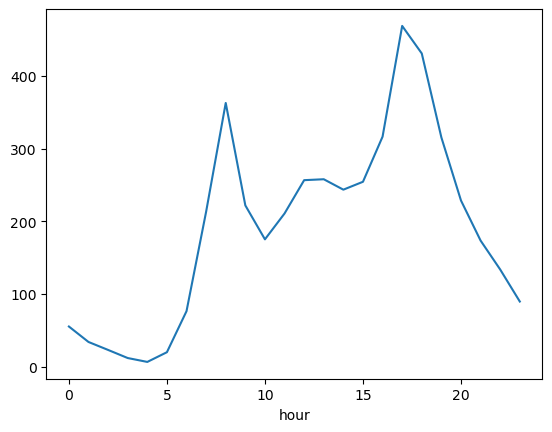

In [9]:
# mean rentals for each value of "hour"
bikes.groupby('hour').total.mean().plot()

Plot for workingday == 0 and workingday == 1

<Axes: xlabel='hour'>

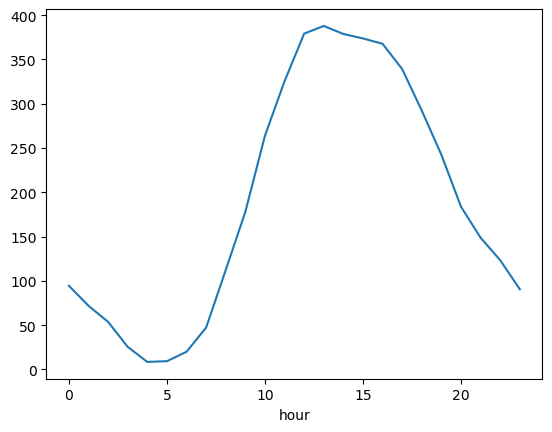

In [10]:
# hourly rental trend for "workingday=0"
bikes[bikes.workingday==0].groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

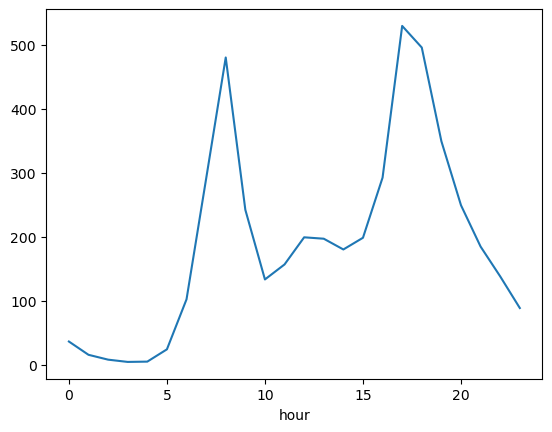

In [11]:
# hourly rental trend for "workingday=1"
bikes[bikes.workingday==1].groupby('hour').total.mean().plot()

<Axes: xlabel='hour'>

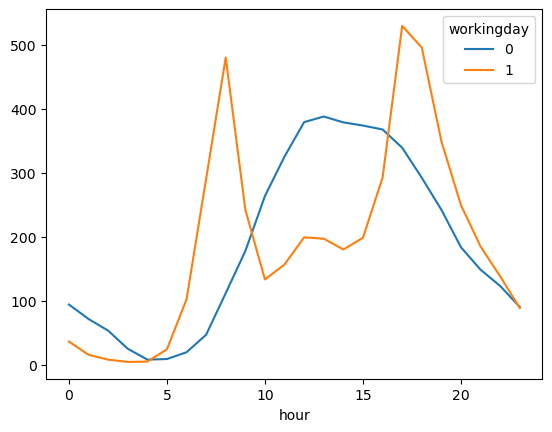

In [12]:
# combine the two plots
bikes.groupby(['hour', 'workingday']).total.mean().unstack().plot()

Write about your findings

# Exercise 7.3

Fit a linear regression model to the entire dataset, using "total" as the response and "hour" and "workingday" as the only features. Then, print the coefficients and interpret them. What are the limitations of linear regression in this instance?

In [13]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import root_mean_squared_error

X = bikes[["hour", "workingday"]]
X_norm = (X - X.mean()) / X.std()
y = bikes["total"]

linreg1 = Ridge(alpha=10)
linreg1.fit(X_norm, y)

,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",10
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' to shuffle the data.See :term:`Glossary ` for details... versionadded:: 0.17 `random_state` to support Stochastic Average Gradient.",None


In [14]:
pd.concat([X[:4], y[:4]], axis=1)

,hour,workingday,total
datetime,,,
2011-01-01 00:00:00,0,0,16
2011-01-01 01:00:00,1,0,40
2011-01-01 02:00:00,2,0,32
2011-01-01 03:00:00,3,0,13


In [15]:
linreg1.intercept_ + linreg1.coef_ @ np.array([4, 0])

np.float64(481.5533724068724)

In [16]:
linreg1.intercept_

np.float64(191.57413191254824)

In [17]:
linreg1.coef_

array([72.49481012,  1.89686932])

# Exercice 7.4

Create a Decision Tree to forecast "total" by manually iterating over the features "hour" and "workingday". The algorithm must at least have 6 end nodes.

In [18]:
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


In [41]:
bikes.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'total', 'hour',
       'pred'],
      dtype='str')

In [52]:
# We can use both hour and workingday are not continuous features, so candidate
# cut point can be chosen from their categories, instead of binning.
def calculate_rmse(branch: pd.DataFrame, target_col: str):
    return ((branch["pred"] - branch[target_col])**2).mean() ** 0.5

def choose_split_point(branch: pd.DataFrame, target_col: str, feature):
    points = branch[feature].unique()
    rmse_pts = []

    for pt in points:
        branch["pred"] = branch[target_col][branch[feature] < pt].mean()
        branch.loc[branch[feature] >= pt, "pred"] = branch[target_col][branch[feature] >= pt].mean()
        
        rmse_pts.append(calculate_rmse(branch, target_col))
        
    chosen_index = rmse_pts.index(min(rmse_pts))
    return points[chosen_index], rmse_pts[chosen_index]

def choose_split_feature(branch: pd.DataFrame, target_col: str):
    features = [ft for ft in branch.columns if ft not in [target_col, "pred"]]
    ft_pts = []
    rmse_fts = []

    for ft in features:
        split_pt, rmse = choose_split_point(branch, target_col, ft)
        ft_pts.append(split_pt)
        rmse_fts.append(rmse)

        print(ft, rmse)
    
    chosen_index = rmse_fts.index(min(rmse_fts))
    return features[chosen_index], ft_pts[chosen_index], rmse_fts[chosen_index]

def split_branch(branch: pd.DataFrame, target_col: str):
    split_ft, split_pt, rmse = choose_split_feature(branch, target_col)

    # Predict
    branch["pred"] = branch[target_col][branch[split_ft] < split_pt].mean()
    branch.loc[branch[split_ft] >= split_pt, "pred"] = branch[target_col][branch[split_ft] >= split_pt].mean()

    return split_ft, split_pt, rmse

# Stop criteria: At least 6 end nodes

In [53]:
cols = ["hour", "workingday", "total"]
tree = bikes[cols].copy()
split_branch(tree, "total")

hour 150.22560060405678
workingday 181.12395921110559


('hour', np.int32(7), np.float64(150.22560060405678))

In [ ]:
tree_left = tree.loc[tree["hour"] < 7].copy()
split_branch(tree_left, "total")

hour 35.244269462270296
workingday 39.18093811435607


('hour', np.int32(6), np.float64(35.244269462270296))

In [55]:
tree_right = tree.loc[tree["hour"] >= 7].copy()
split_branch(tree_right, "total")

hour 166.69864069956617
workingday 176.22450578246955


('hour', np.int32(21), np.float64(166.69864069956617))

In [56]:
tree_right_left = tree_right.loc[tree_right["hour"] < 21].copy()
split_branch(tree_right_left, "total")

hour 172.42676054580915
workingday 179.98131815713614


('hour', np.int32(16), np.float64(172.42676054580915))

In [57]:
tree_right_right = tree_right.loc[tree_right["hour"] >= 21].copy()
split_branch(tree_right_right, "total")

hour 72.98864033487487
workingday 78.59722825511939


('hour', np.int32(23), np.float64(72.98864033487487))

In [69]:
tree_right_left_left = tree_right_left.loc[tree_right_left["hour"] < 16].copy()
split_branch(tree_right_left_left, "total")

hour 154.95247130836916
workingday 155.56614105625218


('hour', np.int32(9), np.float64(154.95247130836916))

In [70]:
tree_right_left_right = tree_right_left.loc[tree_right_left["hour"] >= 16].copy()
split_branch(tree_right_left_right, "total")

hour 186.41275084200595
workingday 192.18389017185353


('hour', np.int32(19), np.float64(186.41275084200595))

In [65]:
tree.pred.unique()

array([ 32.58203249, 255.99599845])

In [71]:
split_branches = [tree, tree_left, tree_right, tree_right_left, tree_right_right, tree_right_left_left, tree_right_left_right]

def update_predict(data, split_branches):
    for branch in split_branches:
        indices = branch.index

        data.loc[indices, "pred"] = branch.loc[indices, "pred"]

update_predict(bikes, split_branches)

In [72]:
bikes.pred.unique()

array([ 25.17771982,  76.25934066, 287.94285714, 231.3963625 ,
       405.33260234, 271.89802632, 153.47368421,  89.50877193])

In [73]:
calculate_rmse(bikes, "total")

np.float64(131.70624376629758)

In [ ]:
#         |(tree)
#  ---------------
#  |(l)          |(r)
# ---       -----------
# | |       |(r_l)    |(r_r)
#        -----------------
#        |     |   |     |
#       ---   ---
#       | |   | |

# Exercise 7.5

Train a Decision Tree using scikit-learn. Comment about the performance of the models.

In [74]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score

X = bikes[["hour", "workingday"]]
y = bikes["total"]

treereg = DecisionTreeRegressor(random_state=42)
scores = cross_val_score(treereg, X, y, cv=14, scoring='neg_mean_squared_error')
np.mean(np.sqrt(-scores))

np.float64(105.19244713068338)

In [87]:
treereg1 = DecisionTreeRegressor(max_depth=4, random_state=42)
scores = cross_val_score(treereg1, X, y, cv=14, scoring='neg_mean_squared_error')
np.mean(np.sqrt(-scores))

np.float64(130.68509503469252)

In [90]:
# list of values to try
max_depth_range = range(3, 15)

# list to store the average RMSE for each value of max_depth
RMSE_scores = []

# use LOOCV with each value of max_depth
for depth in max_depth_range:
    treereg = DecisionTreeRegressor(max_depth=depth, random_state=42)
    MSE_scores = cross_val_score(treereg, X, y, cv=14, scoring='neg_mean_squared_error')
    RMSE_scores.append(np.mean(np.sqrt(-MSE_scores)))

Text(0, 0.5, 'RMSE (lower is better)')

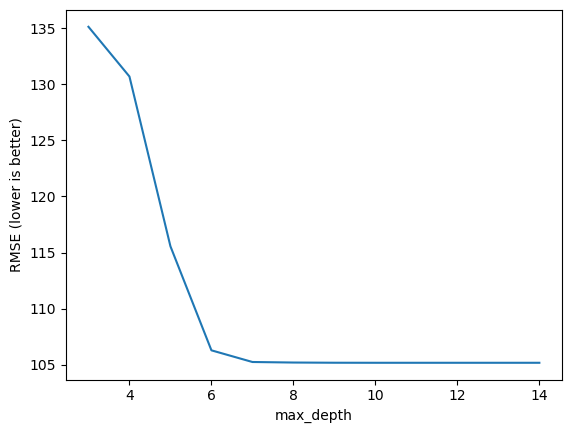

In [91]:
import matplotlib.pyplot as plt
# plot max_depth (x-axis) versus RMSE (y-axis)
plt.plot(max_depth_range, RMSE_scores)
plt.xlabel('max_depth')
plt.ylabel('RMSE (lower is better)')

In [95]:
treereg1.fit(X, y)
pd.DataFrame({'feature':["hour", "workingday"], 'importance':treereg1.feature_importances_})

,feature,importance
0,hour,0.99191
1,workingday,0.00809


Text(0.5, 1.0, 'Bike Rented Prediction Decision Tree')

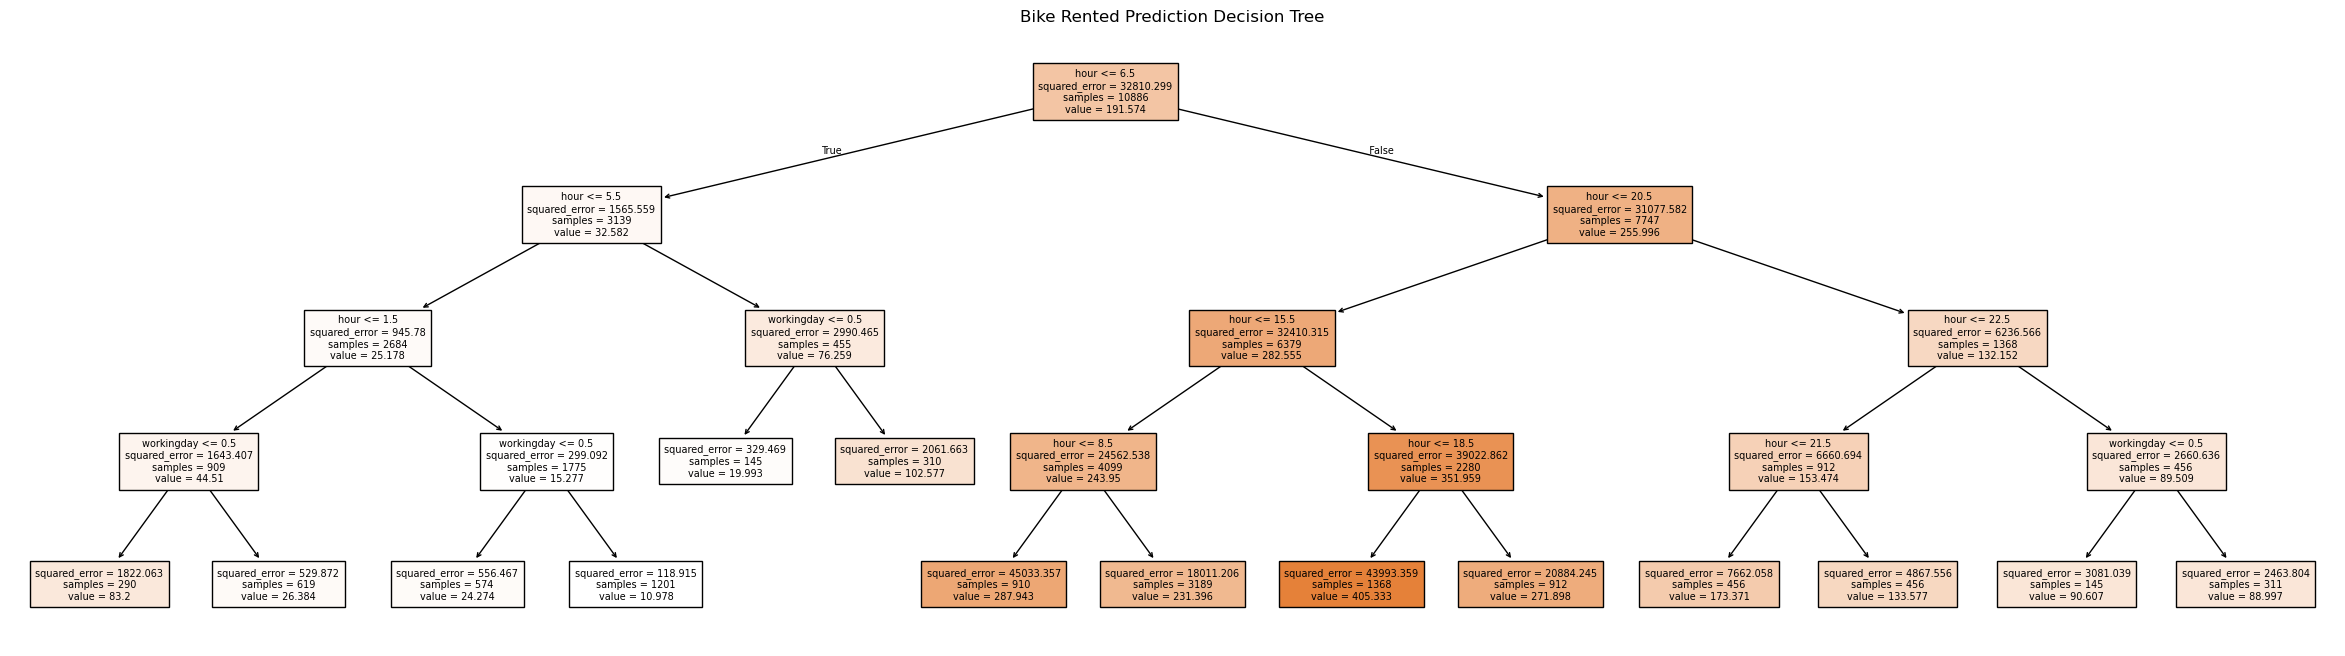

In [112]:
from sklearn.tree import plot_tree

plt.figure(figsize=(30, 8))
plot_tree(
    treereg1,
    feature_names=["hour", "workingday"],
    filled=True,
    rounded=False,
    fontsize=7
)
plt.title("Bike Rented Prediction Decision Tree")